# Breast Cancer Classification Experiment

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

import warnings
warnings.filterwarnings("ignore")

In [3]:
# Create output directory for saving plots
OUTPUT_DIR = os.path.join(os.getcwd(), "outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output directory: {OUTPUT_DIR}")

Output directory: /content/outputs


In [4]:
data = load_breast_cancer()

# Create a readable DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target          # 0 = Malignant, 1 = Benign
df["diagnosis"] = df["target"].map({0: "Malignant", 1: "Benign"})

print("=" * 55)
print("       BREAST CANCER CLASSIFICATION EXPERIMENT")
print("=" * 55)
print(f"\n📊 Dataset Shape : {df.shape}")
print(f"✅ Benign        : {(df.target == 1).sum()} samples")
print(f"❌ Malignant     : {(df.target == 0).sum()} samples")
print(f"\n🔬 Feature Names (first 5): {list(data.feature_names[:5])}")
print(f"\n--- First 5 rows ---")
print(df[["mean radius", "mean texture", "mean area", "diagnosis"]].head())

       BREAST CANCER CLASSIFICATION EXPERIMENT

📊 Dataset Shape : (569, 32)
✅ Benign        : 357 samples
❌ Malignant     : 212 samples

🔬 Feature Names (first 5): [np.str_('mean radius'), np.str_('mean texture'), np.str_('mean perimeter'), np.str_('mean area'), np.str_('mean smoothness')]

--- First 5 rows ---
   mean radius  mean texture  mean area  diagnosis
0        17.99         10.38     1001.0  Malignant
1        20.57         17.77     1326.0  Malignant
2        19.69         21.25     1203.0  Malignant
3        11.42         20.38      386.1  Malignant
4        20.29         14.34     1297.0  Malignant


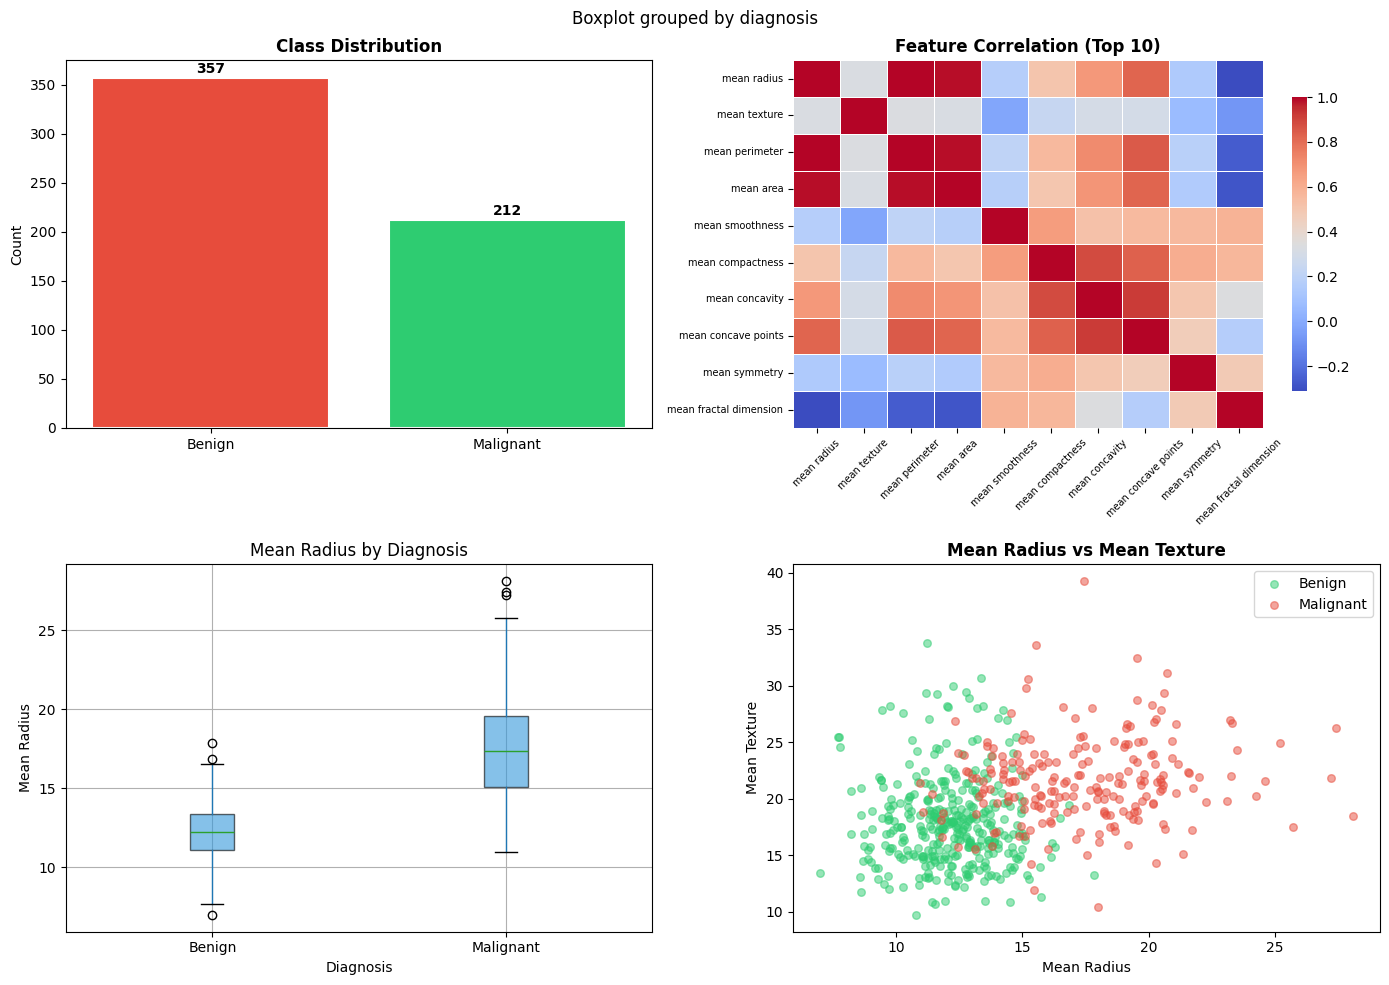

✅ EDA plots saved.


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Breast Cancer Dataset - Exploratory Data Analysis", fontsize=15, fontweight="bold")

# 4a. Class distribution
ax = axes[0, 0]
counts = df["diagnosis"].value_counts()
colors = ["#e74c3c", "#2ecc71"]
bars = ax.bar(counts.index, counts.values, color=colors, edgecolor="white", linewidth=1.5)
ax.set_title("Class Distribution", fontweight="bold")
ax.set_ylabel("Count")
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(val), ha="center", fontweight="bold")

# 4b. Feature correlation heatmap (top 10 features)
ax = axes[0, 1]
top_features = df[data.feature_names[:10]].corr()
sns.heatmap(top_features, ax=ax, cmap="coolwarm", annot=False,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
ax.set_title("Feature Correlation (Top 10)", fontweight="bold")
ax.tick_params(axis="x", rotation=45, labelsize=7)
ax.tick_params(axis="y", labelsize=7)

# 4c. Boxplot - mean radius by class
ax = axes[1, 0]
df.boxplot(column="mean radius", by="diagnosis", ax=ax,
           patch_artist=True,
           boxprops=dict(facecolor="#3498db", alpha=0.6))
ax.set_title("Mean Radius by Diagnosis", fontweight="bold")
ax.set_xlabel("Diagnosis")
ax.set_ylabel("Mean Radius")
plt.sca(ax)
plt.title("Mean Radius by Diagnosis")

# 4d. Scatter plot - mean radius vs mean texture
ax = axes[1, 1]
colors_map = {"Malignant": "#e74c3c", "Benign": "#2ecc71"}
for label, grp in df.groupby("diagnosis"):
    ax.scatter(grp["mean radius"], grp["mean texture"],
               label=label, color=colors_map[label], alpha=0.5, s=30)
ax.set_xlabel("Mean Radius")
ax.set_ylabel("Mean Texture")
ax.set_title("Mean Radius vs Mean Texture", fontweight="bold")
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "eda_plots.png"), dpi=150, bbox_inches="tight")
plt.show()
print("✅ EDA plots saved.")

In [6]:
X = df[data.feature_names]
y = df["target"]

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"✂️  Train size : {X_train.shape[0]} | Test size : {X_test.shape[0]}")

✂️  Train size : 455 | Test size : 114


In [7]:
models = {
    "Logistic Regression" : LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree"       : DecisionTreeClassifier(random_state=42),
    "Random Forest"       : RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM (RBF)"           : SVC(kernel="rbf", probability=True, random_state=42),
    "K-Nearest Neighbors" : KNeighborsClassifier(n_neighbors=5),
}

results = {}
print("\n" + "=" * 55)
print("          MODEL TRAINING & CROSS-VALIDATION")
print("=" * 55)

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring="accuracy")
    test_acc  = model.score(X_test_scaled, y_test)
    results[name] = {
        "model"     : model,
        "cv_mean"   : cv_scores.mean(),
        "cv_std"    : cv_scores.std(),
        "test_acc"  : test_acc,
    }
    print(f"\n🔹 {name}")
    print(f"   CV Accuracy : {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%")
    print(f"   Test Acc    : {test_acc*100:.2f}%")


          MODEL TRAINING & CROSS-VALIDATION

🔹 Logistic Regression
   CV Accuracy : 98.02% ± 1.28%
   Test Acc    : 98.25%

🔹 Decision Tree
   CV Accuracy : 90.99% ± 1.89%
   Test Acc    : 91.23%

🔹 Random Forest
   CV Accuracy : 95.38% ± 2.35%
   Test Acc    : 95.61%

🔹 SVM (RBF)
   CV Accuracy : 97.14% ± 1.79%
   Test Acc    : 98.25%

🔹 K-Nearest Neighbors
   CV Accuracy : 96.70% ± 2.09%
   Test Acc    : 95.61%


In [8]:
best_name = max(results, key=lambda k: results[k]["test_acc"])
best_model = results[best_name]["model"]

print("\n" + "=" * 55)
print(f"  🏆 BEST MODEL : {best_name}")
print("=" * 55)

y_pred = best_model.predict(X_test_scaled)
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Malignant", "Benign"]))


  🏆 BEST MODEL : Logistic Regression

📋 Classification Report:
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



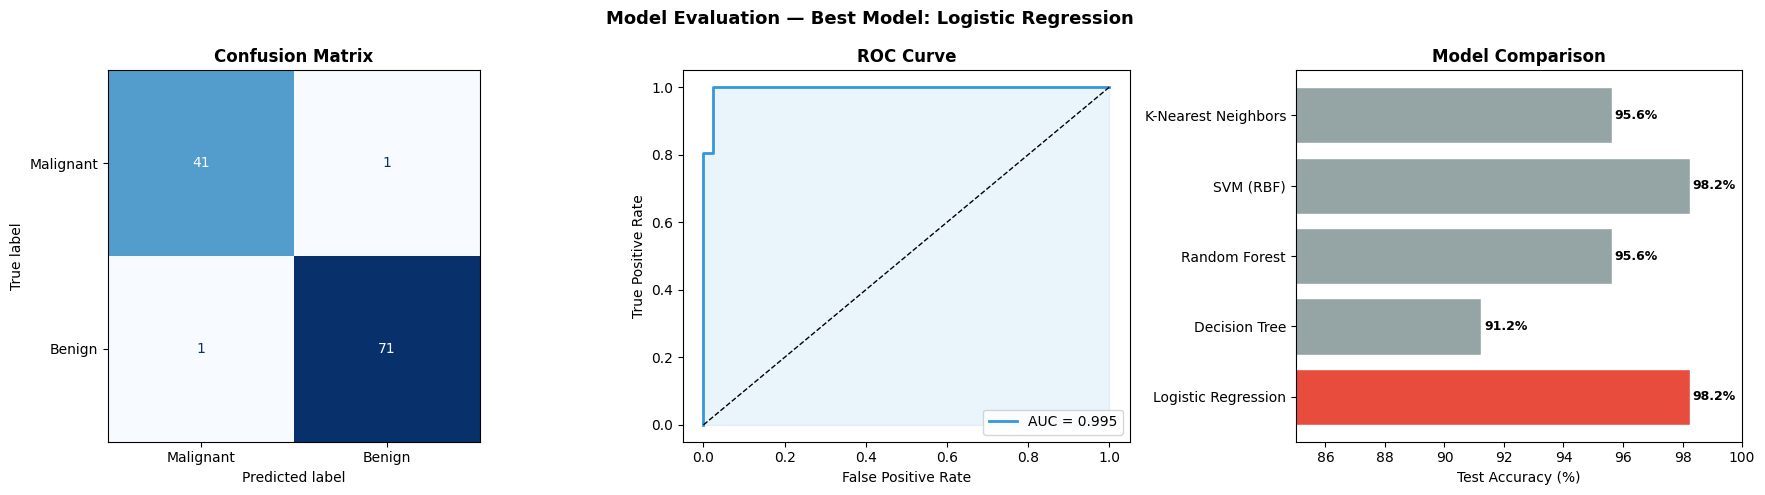

✅ Result plots saved.


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"Model Evaluation — Best Model: {best_name}", fontsize=13, fontweight="bold")

# 8a. Confusion Matrix
ax = axes[0]
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Malignant", "Benign"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix", fontweight="bold")

# 8b. ROC Curve
ax = axes[1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
ax.plot(fpr, tpr, color="#3498db", lw=2, label=f"AUC = {roc_auc:.3f}")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.fill_between(fpr, tpr, alpha=0.1, color="#3498db")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve", fontweight="bold")
ax.legend(loc="lower right")

# 8c. Model Comparison Bar Chart
ax = axes[2]
model_names = list(results.keys())
test_accs   = [results[m]["test_acc"] * 100 for m in model_names]
bar_colors  = ["#e74c3c" if m == best_name else "#95a5a6" for m in model_names]
bars = ax.barh(model_names, test_accs, color=bar_colors, edgecolor="white")
ax.set_xlabel("Test Accuracy (%)")
ax.set_title("Model Comparison", fontweight="bold")
ax.set_xlim(85, 100)
for bar, acc in zip(bars, test_accs):
    ax.text(acc + 0.1, bar.get_y() + bar.get_height()/2,
            f"{acc:.1f}%", va="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "model_results.png"), dpi=150, bbox_inches="tight")
plt.show()
print("✅ Result plots saved.")

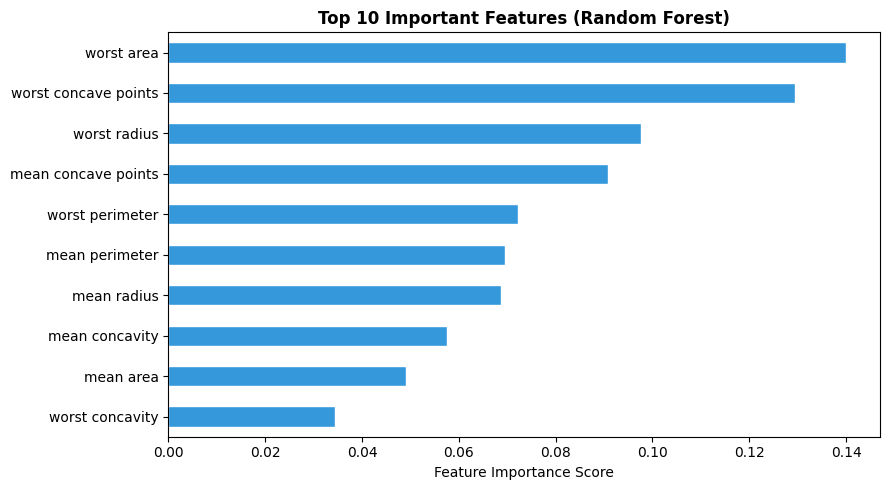

✅ Feature importance plot saved.


In [10]:
rf_model = results["Random Forest"]["model"]
importances = pd.Series(rf_model.feature_importances_, index=data.feature_names)
top10 = importances.nlargest(10)

plt.figure(figsize=(9, 5))
top10.sort_values().plot(kind="barh", color="#3498db", edgecolor="white")
plt.title("Top 10 Important Features (Random Forest)", fontweight="bold")
plt.xlabel("Feature Importance Score")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "feature_importance.png"), dpi=150, bbox_inches="tight")
plt.show()
print("✅ Feature importance plot saved.")

In [11]:
print("\n" + "=" * 55)
print("              FINAL RESULTS SUMMARY")
print("=" * 55)
summary_df = pd.DataFrame({
    "Model"        : list(results.keys()),
    "CV Accuracy"  : [f"{results[m]['cv_mean']*100:.2f}%" for m in results],
    "CV Std Dev"   : [f"±{results[m]['cv_std']*100:.2f}%" for m in results],
    "Test Accuracy": [f"{results[m]['test_acc']*100:.2f}%" for m in results],
}).set_index("Model")
print(summary_df.to_string())
print(f"\n🏆 Best Model    : {best_name}")
print(f"   Test Accuracy : {results[best_name]['test_acc']*100:.2f}%")
print(f"   ROC-AUC Score : {roc_auc:.4f}")
print("\n✅ Experiment complete!")


              FINAL RESULTS SUMMARY
                    CV Accuracy CV Std Dev Test Accuracy
Model                                                   
Logistic Regression      98.02%     ±1.28%        98.25%
Decision Tree            90.99%     ±1.89%        91.23%
Random Forest            95.38%     ±2.35%        95.61%
SVM (RBF)                97.14%     ±1.79%        98.25%
K-Nearest Neighbors      96.70%     ±2.09%        95.61%

🏆 Best Model    : Logistic Regression
   Test Accuracy : 98.25%
   ROC-AUC Score : 0.9954

✅ Experiment complete!
